In [65]:
import pandas as pd

In [66]:
data=pd.read_csv("force_coefficients.csv").drop(columns=["file"])

In [67]:
data

,time,Fx,Fy,Cd,Cl
0,0.00,0.000000,0.000000e+00,0.000000,0.000000e+00
1,0.01,142.465745,-2.319725e-07,364.712307,-5.938496e-07
2,0.02,94.979430,-2.753755e-07,243.147341,-7.049612e-07
3,0.03,68.405185,-2.562905e-07,175.117273,-6.561038e-07
4,0.04,52.031205,-4.301872e-08,133.199885,-1.101279e-07
...,...,...,...,...,...
496,4.96,-1.344603,6.940984e-01,-3.442184,1.776892e+00
497,4.97,-1.489648,5.996121e-01,-3.813498,1.535007e+00
498,4.98,-1.435313,3.664183e-01,-3.674400,9.380308e-01
499,4.99,-1.257114,7.113573e-02,-3.218212,1.821075e-01


Text(0, 0.5, 'Cd')

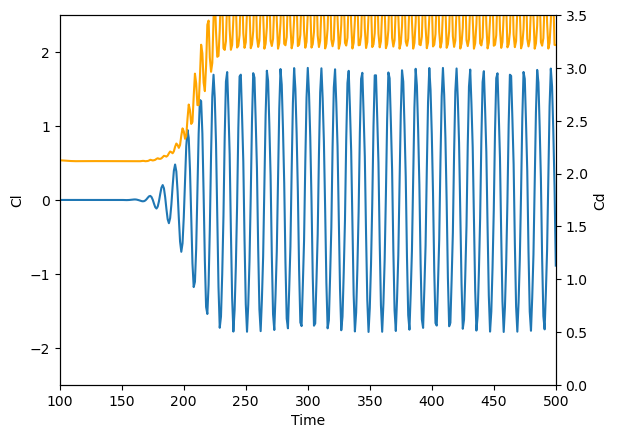

In [68]:
ax = data['Cl'].plot()
ax.set_xlim(100, 500)
ax.set_ylim(-2.5, 2.5)
# move Cd to the right y-axis
ax2 = ax.twinx()
abs(data['Cd']).plot(ax=ax2, color='orange')
ax2.set_ylim(0, 3.5)
ax.set_xlabel("Time")
ax.set_ylabel("Cl")
ax2.set_ylabel("Cd")    

In [69]:
# RMS values of Cl and Cd over the time range 100 to 500 (make sure to only consider the data in this time range for the calculation). The length scale is 0.25 and the velocity scale is 10.

import numpy as np
cl_rms = np.sqrt(np.mean(data[(data['time'] >= 0) & (data['time'] <= 100)]['Cl']**2))
cd_rms = np.sqrt(np.mean(data[(data['time'] >= 0) & (data['time'] <= 100)]['Cd']**2))
print(f"RMS Cl: {cl_rms}")
print(f"RMS Cd: {cd_rms}")

RMS Cl: 0.9338503027582042
RMS Cd: 23.568359430955223


In [70]:
# calculate strouhal number based on the dominant frequency in the Cl signal (between 100 and 500  time units  )
from scipy.signal import find_peaks
peaks, _ = find_peaks(data['Cl'][200:500], height=0)
peak_times = data['time'][200:500].iloc[peaks]
dominant_frequency = 1 / np.mean(np.diff(peak_times))
print("Dominant frequency:", dominant_frequency)


# lenght 0.25 and velocity 10
strouhal_number = dominant_frequency * 0.25 / 10
print("Strouhal number:", strouhal_number)



Dominant frequency: 9.215017064846416
Strouhal number: 0.2303754266211604


Found 501 VTU files
D    = 0.25
LZ   = 0.03125
AREF = 0.0078125
UREF = 10.0

[    1/  501] t=0.00000, Cd=0.000000, Cl=0.000000


/tmp/ipykernel_2473726/628289267.py:176: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = mesh.extract_surface()


[   26/  501] t=0.25000, Cd=-0.897931, Cl=-0.000001
[   51/  501] t=0.50000, Cd=2.204654, Cl=-0.000001
[   76/  501] t=0.75000, Cd=2.166615, Cl=0.000001
[  101/  501] t=1.00000, Cd=2.125394, Cl=0.000001
[  126/  501] t=1.25000, Cd=2.117777, Cl=0.000027
[  151/  501] t=1.50000, Cd=2.116265, Cl=0.000047
[  176/  501] t=1.75000, Cd=2.123807, Cl=-0.000908
[  201/  501] t=2.00000, Cd=2.399018, Cl=0.232024
[  226/  501] t=2.25000, Cd=3.713854, Cl=-1.375032
[  251/  501] t=2.50000, Cd=3.242285, Cl=1.409678
[  276/  501] t=2.75000, Cd=3.454249, Cl=0.701800
[  301/  501] t=3.00000, Cd=3.513446, Cl=-1.786073
[  326/  501] t=3.25000, Cd=3.182264, Cl=0.233428
[  351/  501] t=3.50000, Cd=3.835418, Cl=1.464165
[  376/  501] t=3.75000, Cd=3.230640, Cl=-1.168461
[  401/  501] t=4.00000, Cd=3.632820, Cl=-0.894064
[  426/  501] t=4.25000, Cd=3.379729, Cl=1.743135
[  451/  501] t=4.50000, Cd=3.210105, Cl=0.137784
[  476/  501] t=4.75000, Cd=3.764224, Cl=-1.636832
[  501/  501] t=5.00000, Cd=3.216692, Cl=

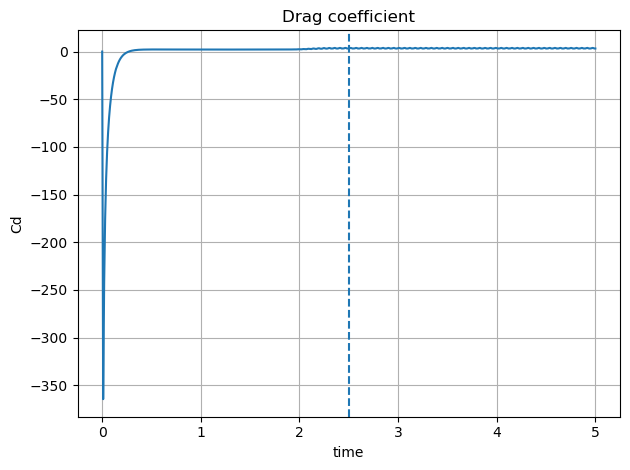

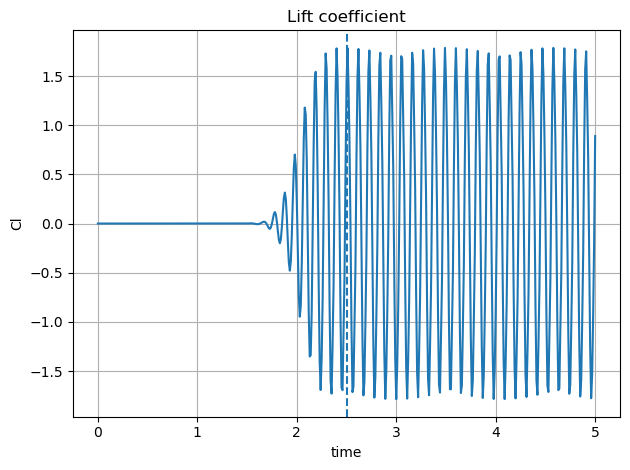

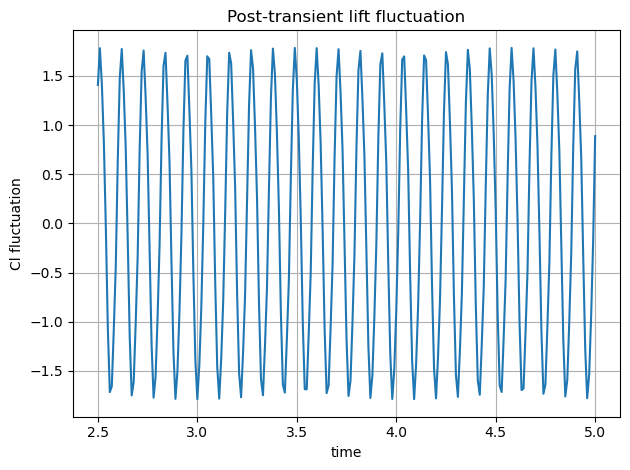

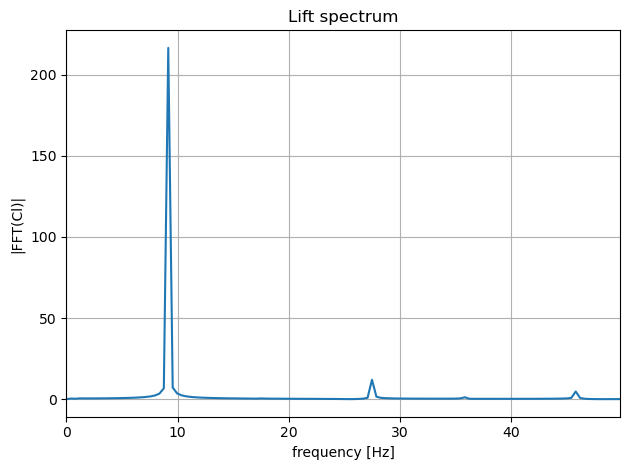

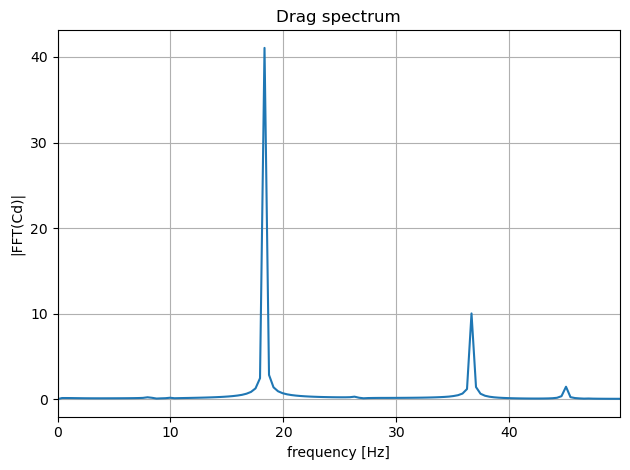

In [71]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks


# ============================================================
# USER SETTINGS
# ============================================================

VTU_PATTERN = "./cases/rectangle_2D/output/*.vtu"

# Solver/output time settings
DT_SOLVER = 1.0e-4
OUTPUT_INTERVAL = 100
DT_OUTPUT = DT_SOLVER * OUTPUT_INTERVAL

# Flow properties
RHO = 1.0
NU = 1.0e-2
MU = RHO * NU

# Reference values
UREF = 10.0

# Obstacle geometry from your mesh
X1 = 1.0
X2 = 1.25
Y1 = 0.375
Y2 = 0.625

D = X2 - X1

# One-cell-thick z-depth from your mesh
LZ = 1.0 / 32.0

# Reference area for full 3D-extruded force
AREF = D * LZ

# Surface-selection tolerance
TOL = 1.0e-7

# Discard this fraction of the beginning when computing statistics/frequency
TRANSIENT_FRACTION = 0.5

# If mean Cd is negative after transient, flip force sign automatically
AUTO_FLIP_FORCE_SIGN = True

# Output files
CSV_OUT = "force_coefficients.csv"
PLOTS_DIR = "post_plots"

# Possible pressure names in your VTU
PRESSURE_CANDIDATES = ["p", "pressure", "Pressure", "P"]


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def natural_sort_key(path):
    """
    Sort files like output_1.vtu, output_2.vtu, ..., output_10.vtu correctly.
    """
    s = str(path)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def find_array_name(mesh, candidates):
    """
    Find array name in point_data or cell_data.
    """
    available = list(mesh.point_data.keys()) + list(mesh.cell_data.keys())

    for name in candidates:
        if name in available:
            return name

    raise KeyError(
        f"Could not find any of {candidates}. "
        f"Available arrays are: {available}"
    )


def get_cell_array(grid, array_name):
    """
    Return an array as cell-centered data.
    If it is point data, convert to cell data.
    """
    if array_name in grid.cell_data:
        return np.asarray(grid.cell_data[array_name])

    if array_name in grid.point_data:
        tmp = grid.point_data_to_cell_data()
        return np.asarray(tmp.cell_data[array_name])

    raise KeyError(
        f"Array '{array_name}' not found. "
        f"Point arrays: {list(grid.point_data.keys())}, "
        f"Cell arrays: {list(grid.cell_data.keys())}"
    )


def obstacle_mask_and_normals(surface):
    """
    Identify obstacle boundary faces and assign solid outward normals.

    Solid outward normals:
      left obstacle face:   (-1,  0, 0)
      right obstacle face:  ( 1,  0, 0)
      bottom obstacle face: ( 0, -1, 0)
      top obstacle face:    ( 0,  1, 0)

    These are normals of the solid obstacle pointing into the fluid.
    Pressure force on the solid is: Fp = integral(-p * n_solid dA)
    """
    centers = surface.cell_centers().points
    cx = centers[:, 0]
    cy = centers[:, 1]

    on_left = (
        np.isclose(cx, X1, atol=TOL)
        & (cy >= Y1 - TOL)
        & (cy <= Y2 + TOL)
    )

    on_right = (
        np.isclose(cx, X2, atol=TOL)
        & (cy >= Y1 - TOL)
        & (cy <= Y2 + TOL)
    )

    on_bottom = (
        np.isclose(cy, Y1, atol=TOL)
        & (cx >= X1 - TOL)
        & (cx <= X2 + TOL)
    )

    on_top = (
        np.isclose(cy, Y2, atol=TOL)
        & (cx >= X1 - TOL)
        & (cx <= X2 + TOL)
    )

    mask = on_left | on_right | on_bottom | on_top

    normals = np.zeros((surface.n_cells, 3), dtype=float)
    normals[on_left, :] = [-1.0, 0.0, 0.0]
    normals[on_right, :] = [1.0, 0.0, 0.0]
    normals[on_bottom, :] = [0.0, -1.0, 0.0]
    normals[on_top, :] = [0.0, 1.0, 0.0]

    return mask, normals


def compute_pressure_force(filename):
    """
    Compute pressure force on obstacle from one VTU file.

    This calculates pressure-only force:
        Fp = integral(-p * n_solid dA)

    It does NOT include viscous shear force.
    """
    mesh = pv.read(filename)

    p_name = find_array_name(mesh, PRESSURE_CANDIDATES)

    # Extract all external and internal boundary faces
    surface = mesh.extract_surface()

    # Compute face areas
    surface = surface.compute_cell_sizes(
        length=False,
        area=True,
        volume=False
    )

    area_all = np.asarray(surface.cell_data["Area"])

    mask, normals_all = obstacle_mask_and_normals(surface)

    if np.count_nonzero(mask) == 0:
        raise RuntimeError(
            f"No obstacle faces found in file: {filename}\n"
            f"Try increasing TOL. Current TOL = {TOL}"
        )

    obs = surface.extract_cells(mask)
    obs = obs.compute_cell_sizes(length=False, area=True, volume=False)

    p_cell = get_cell_array(obs, p_name)
    area = np.asarray(obs.cell_data["Area"])

    # Need normals corresponding only to selected obstacle cells
    normals = normals_all[mask]

    # Pressure force on solid obstacle
    # F = integral(-p n_solid dA)
    Fp_cells = -p_cell[:, None] * normals * area[:, None]
    Fp = np.sum(Fp_cells, axis=0)

    Fx = Fp[0]
    Fy = Fp[1]

    q = 0.5 * RHO * UREF**2

    Cd = Fx / (q * AREF)
    Cl = Fy / (q * AREF)

    return Fx, Fy, Cd, Cl, np.count_nonzero(mask), np.sum(area)


def compute_frequency_fft(t, signal):
    """
    Compute dominant frequency using FFT.
    """
    signal = np.asarray(signal)
    signal = signal - np.mean(signal)

    dt = np.mean(np.diff(t))

    freq = rfftfreq(len(signal), dt)
    amp = np.abs(rfft(signal))

    # Ignore zero frequency
    if len(amp) > 0:
        amp[0] = 0.0

    i_max = np.argmax(amp)
    f_dom = freq[i_max]

    return f_dom, freq, amp


def compute_frequency_peaks(t, signal):
    """
    Compute frequency using peak-to-peak timing.
    Useful as a check against FFT.
    """
    signal = np.asarray(signal)
    signal = signal - np.mean(signal)

    peaks, _ = find_peaks(signal)

    if len(peaks) < 2:
        return np.nan, peaks

    peak_times = t[peaks]
    periods = np.diff(peak_times)

    T_mean = np.mean(periods)
    f_peak = 1.0 / T_mean

    return f_peak, peaks


# ============================================================
# MAIN SCRIPT
# ============================================================

def main():
    Path(PLOTS_DIR).mkdir(exist_ok=True)

    files = sorted(glob.glob(VTU_PATTERN), key=natural_sort_key)

    if len(files) == 0:
        raise RuntimeError(f"No VTU files found with pattern: {VTU_PATTERN}")

    print(f"Found {len(files)} VTU files")
    print(f"D    = {D}")
    print(f"LZ   = {LZ}")
    print(f"AREF = {AREF}")
    print(f"UREF = {UREF}")
    print()

    rows = []

    for i, filename in enumerate(files):
        time = i * DT_OUTPUT

        Fx, Fy, Cd, Cl, nfaces, obs_area = compute_pressure_force(filename)

        rows.append(
            {
                "time": time,
                "Fx": Fx,
                "Fy": Fy,
                "Cd": Cd,
                "Cl": Cl,
                "n_obstacle_faces": nfaces,
                "obstacle_area": obs_area,
                "file": filename,
            }
        )

        if i % 25 == 0 or i == len(files) - 1:
            print(
                f"[{i + 1:5d}/{len(files):5d}] "
                f"t={time:.5f}, Cd={Cd:.6f}, Cl={Cl:.6f}"
            )

    df = pd.DataFrame(rows)

    # --------------------------------------------------------
    # Optional automatic force-sign correction
    # --------------------------------------------------------
    start = int(TRANSIENT_FRACTION * len(df))

    mean_cd_raw = df["Cd"].iloc[start:].mean()

    if AUTO_FLIP_FORCE_SIGN and mean_cd_raw < 0.0:
        print()
        print("Mean Cd after transient is negative.")
        print("Flipping Fx, Fy, Cd, and Cl signs.")
        df["Fx"] *= -1.0
        df["Fy"] *= -1.0
        df["Cd"] *= -1.0
        df["Cl"] *= -1.0

    df.to_csv(CSV_OUT, index=False)
    print()
    print(f"Wrote: {CSV_OUT}")

    # --------------------------------------------------------
    # Statistics after transient
    # --------------------------------------------------------
    t = df["time"].to_numpy()
    Cd = df["Cd"].to_numpy()
    Cl = df["Cl"].to_numpy()

    t2 = t[start:]
    Cd2 = Cd[start:]
    Cl2 = Cl[start:]

    Cd_mean = np.mean(Cd2)
    Cl_mean = np.mean(Cl2)

    Cd_rms_fluct = np.sqrt(np.mean((Cd2 - Cd_mean) ** 2))
    Cl_rms_fluct = np.sqrt(np.mean((Cl2 - Cl_mean) ** 2))

    print()
    print("Post-transient statistics")
    print("-------------------------")
    print(f"Transient discarded: first {TRANSIENT_FRACTION * 100:.1f}%")
    print(f"Mean Cd             = {Cd_mean:.8f}")
    print(f"Mean Cl             = {Cl_mean:.8f}")
    print(f"RMS Cd fluctuation  = {Cd_rms_fluct:.8f}")
    print(f"RMS Cl fluctuation  = {Cl_rms_fluct:.8f}")

    # --------------------------------------------------------
    # Frequency and Strouhal from signed Cl
    # --------------------------------------------------------
    f_cl_fft, freq_cl, amp_cl = compute_frequency_fft(t2, Cl2)
    St_cl_fft = f_cl_fft * D / UREF

    f_cl_peaks, peaks_cl = compute_frequency_peaks(t2, Cl2)
    St_cl_peaks = f_cl_peaks * D / UREF if np.isfinite(f_cl_peaks) else np.nan

    # Also compute CD frequency to confirm expected 2x behavior
    f_cd_fft, freq_cd, amp_cd = compute_frequency_fft(t2, Cd2)
    St_cd_fft = f_cd_fft * D / UREF

    print()
    print("Frequency results")
    print("-----------------")
    print(f"FFT frequency from signed Cl = {f_cl_fft:.8f} Hz")
    print(f"FFT Strouhal from Cl         = {St_cl_fft:.8f}")
    print()
    print(f"Peak frequency from Cl       = {f_cl_peaks:.8f} Hz")
    print(f"Peak Strouhal from Cl        = {St_cl_peaks:.8f}")
    print()
    print(f"FFT frequency from Cd        = {f_cd_fft:.8f} Hz")
    print(f"FFT Strouhal from Cd         = {St_cd_fft:.8f}")
    print(f"Half of Cd-based St          = {0.5 * St_cd_fft:.8f}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------

    plt.figure()
    plt.plot(t, Cd)
    plt.axvline(t[start], linestyle="--")
    plt.xlabel("time")
    plt.ylabel("Cd")
    plt.title("Drag coefficient")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/Cd_timeseries.png", dpi=200)

    plt.figure()
    plt.plot(t, Cl)
    plt.axvline(t[start], linestyle="--")
    plt.xlabel("time")
    plt.ylabel("Cl")
    plt.title("Lift coefficient")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/Cl_timeseries.png", dpi=200)

    plt.figure()
    plt.plot(t2, Cl2 - np.mean(Cl2))
    plt.xlabel("time")
    plt.ylabel("Cl fluctuation")
    plt.title("Post-transient lift fluctuation")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/Cl_post_transient.png", dpi=200)

    plt.figure()
    plt.plot(freq_cl, amp_cl)
    plt.xlim(0.0, min(50.0, np.max(freq_cl)))
    plt.xlabel("frequency [Hz]")
    plt.ylabel("|FFT(Cl)|")
    plt.title("Lift spectrum")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/Cl_fft.png", dpi=200)

    plt.figure()
    plt.plot(freq_cd, amp_cd)
    plt.xlim(0.0, min(50.0, np.max(freq_cd)))
    plt.xlabel("frequency [Hz]")
    plt.ylabel("|FFT(Cd)|")
    plt.title("Drag spectrum")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/Cd_fft.png", dpi=200)

    print()
    print(f"Wrote plots to: {PLOTS_DIR}/")


if __name__ == "__main__":
    main()